In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -r "/content/drive/MyDrive/GEO_AI_Cropland_Mapping_Challenge/requirements.txt"

In [3]:
import pandas as pd
import numpy as np
import os
import random
import time
import json
from joblib import load

#visualizing
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [4]:
start = time.time()

In [5]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [6]:
DATA_PATH = "/content/drive/MyDrive/4th_place_GEO_AI_Cropland_Mapping_Challenge/"

In [7]:
#path for the best model
MODEL_PATH = DATA_PATH  + "untuned_best_models/1759309875397/"

In [8]:
df_train = pd.read_csv(DATA_PATH + "/Modelling_data/train_data.csv")

In [9]:
df_test = pd.read_csv(DATA_PATH + "/Modelling_data/test_data.csv")

In [10]:
# #infinite values
for df in (df_train, df_test):
    # replace ±inf with NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [11]:
target = 'Cropland'
columns = df_train.columns.difference(['ID', 'region', 'folds',target])
columns

Index(['ACI_m10', 'ACI_m11', 'ACI_m12', 'ACI_m4', 'ACI_m5', 'ACI_m6', 'ACI_m7',
       'ACI_m8', 'ACI_m9', 'ARVI_m1',
       ...
       'vh_vv_ratio_m11', 'vh_vv_ratio_m12', 'vh_vv_ratio_m2',
       'vh_vv_ratio_m3', 'vh_vv_ratio_m4', 'vh_vv_ratio_m5', 'vh_vv_ratio_m6',
       'vh_vv_ratio_m7', 'vh_vv_ratio_m8', 'vh_vv_ratio_m9'],
      dtype='object', length=512)

In [12]:
print(len(columns))

512


In [13]:
feature_cols = [c for c in df_train.columns if c not in ['ID', 'region', 'folds', 'Cropland']]

### FEATURE IMPORTANCE

In [14]:
def load_models(out_dir):
    """Load saved models and metadata."""
    with open(os.path.join(out_dir, "metadata.json")) as f:
        meta = json.load(f)
    models = {r: load(info["path"]) for r, info in meta.items()}
    return models, meta

def get_feature_importance(pipe, feature_cols, X=None, y=None):
    """
    Return a DataFrame of feature importance.
    Uses model's own feature_importances_ or coef_ if available,
    otherwise falls back to permutation importance (needs X,y).
    """
    # If there was feature selection in the pipeline, apply its mask
    if hasattr(pipe, "named_steps"):
        for step in pipe.named_steps.values():
            if hasattr(step, "get_support"):
                mask = step.get_support()
                feature_cols = [c for c, keep in zip(feature_cols, mask) if keep]

    est = pipe.steps[-1][1] if hasattr(pipe, "steps") else pipe

    if hasattr(est, "feature_importances_"):
        imp = est.feature_importances_
    elif hasattr(est, "coef_"):
        coef = np.array(est.coef_)
        imp = np.abs(coef).mean(axis=0) if coef.ndim > 1 else np.abs(coef)
    else:
        if X is None or y is None:
            raise ValueError("Need X and y for permutation importance.")
        X = X[feature_cols]
        imp = permutation_importance(pipe, X, y, n_repeats=10, random_state=42).importances_mean

    return pd.DataFrame({"feature": feature_cols, "importance": imp}).sort_values(
        "importance", ascending=False
    )



In [15]:
def plot_feature_importance(fi_dict, top_n=10):
  """
    Return a barchart of the top 10 features for each region in descending order
    """
  n_regions = len(fi_dict)

  fig, axes = plt.subplots(1, n_regions, figsize=(4*n_regions, 0.3*top_n), sharey=False)

  if n_regions == 1:
      axes = [axes]  # make iterable if only one region

  for ax, (r, df) in zip(axes, fi_dict.items()):
      top = df.head(top_n).iloc[::-1]
      ax.barh(top["feature"], top["importance"])
      ax.set_title(f"Region {r}")
      ax.set_xlabel("Importance")
      ax.tick_params(axis="y", labelsize=8)

  plt.tight_layout()
  plt.show()


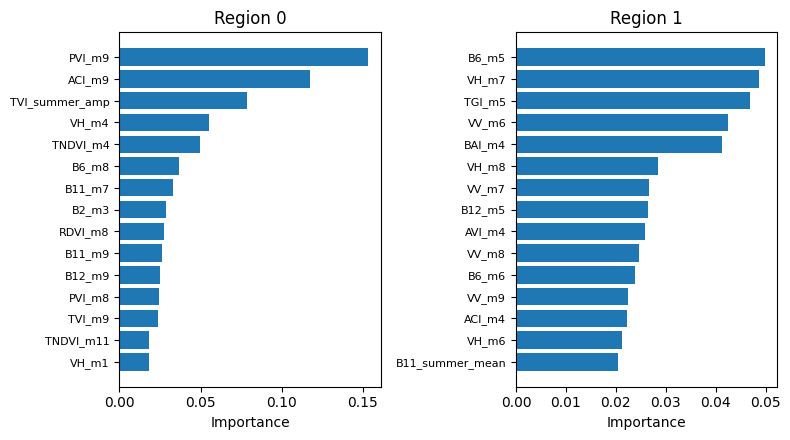

In [16]:
#Feature importance
models, meta = load_models(MODEL_PATH)

fi_dict = {}
for r, pipe in models.items():
    cols = meta[r]["feature_cols"]
    tr = df_train[df_train["region"] == int(r)]
    X, y = tr[cols], tr["Cropland"].astype(int)
    fi_dict[r] = get_feature_importance(pipe, cols, X=X, y=y)

plot_feature_importance(fi_dict, top_n=15)

## USE PRE-SAVED BEST MODELS

In [17]:
def generate_submission_file(df_test, feature_cols, models_dir,
                             out_path="submission.csv",
                             id_col="ID", region_col="region",
                             target_col="Cropland"):
    """
    Use the saved best models from training to generate predictions.

    df_test     : test DataFrame
    feature_cols: list of features
    models_dir  : folder with metadata.json and .pkl models
    out_path    : path for CSV submission
    """

    # 1. Load metadata
    meta_path = os.path.join(models_dir, "metadata.json")
    print(meta_path)
    with open(meta_path, "r") as f:
        meta = json.load(f)

    # 2. Prepare empty list for results
    preds = []

    # 3. Loop over regions
    for r, info in meta.items():
        # load the model for this region
        model_path = info["path"]
        pipe = load(model_path)

        # subset test rows for this region
        test_r = df_test[df_test[region_col].astype(str) == r]
        if test_r.empty:
            continue

        # predict
        Xr = test_r[feature_cols]
        yr_pred = pipe.predict(Xr)

        # collect with IDs
        part = pd.DataFrame({
            id_col: test_r[id_col].values,
            target_col: yr_pred
        })
        preds.append(part)

    # 4. Combine all regions
    submission = pd.concat(preds, axis=0).sort_values(id_col)

    # 5. Save CSV
    submission.to_csv(out_path, index=False)
    print(f"Saved submission to {out_path}")
    return submission


In [18]:
submission = generate_submission_file(
    df_test=df_test,
    feature_cols=feature_cols,
    models_dir=MODEL_PATH,
    out_path=DATA_PATH + "/final_submission.csv",
    id_col="ID",
    region_col="region",
    target_col="Cropland"
)

/content/drive/MyDrive/4th_place_GEO_AI_Cropland_Mapping_Challenge/untuned_best_models/1759309875397/metadata.json
Saved submission to /content/drive/MyDrive/4th_place_GEO_AI_Cropland_Mapping_Challenge//final_submission.csv


In [19]:
submission['Cropland'].value_counts()

,count
Cropland,
0,396
1,204


In [20]:
submission.head()

,ID,Cropland
0,ID_ABQOQT,0
1,ID_ADDROF,0
2,ID_AFIWZH,0
3,ID_AFQOFP,0
0,ID_AHRONV,0


In [21]:
end = time.time()

In [22]:
print("Total time taken to generate submission file using best models : ",(end-start),"seconds")

Total time taken to generate submission file using best models :  6.970892429351807 seconds
